## Hälsostudie - Del 2
##### Fördjupning och pipeline

In [1]:
from src.io_utils import load_data
from src.healthanalyzer import HealthAnalyzer
from src.healthvisualizer import HealthVisualizer 

df = load_data("health_study_dataset.csv")
healthviz = HealthVisualizer(df)
h_analyzer = HealthAnalyzer(df)

Räkna ut medel, median, min och max för: age, weight, height, systolic_bp och cholesterol

In [2]:
from src.metrics import column_stats

column_stats(df)

,Medel,Median,Min,Max
age,49.426250,50.00,18.0,90.00
weight,73.413000,73.20,33.7,114.40
height,171.849250,171.35,144.4,200.40
systolic_bp,149.178625,149.40,106.8,185.90
cholesterol,4.929150,4.97,2.5,7.88



### **Grafer över värden**

- Histogram över blodtryck
- Stapeldiagram över andelen rökare
- Scatter för kolesterol fördelat över åldrar



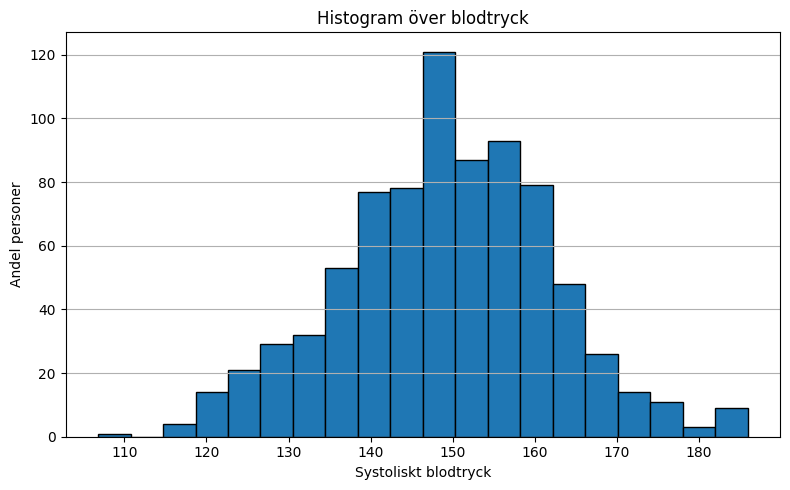

In [3]:
healthviz.plot_hist(column="systolic_bp",
    title="Histogram över blodtryck",
    xlabel="Systoliskt blodtryck",
    ylabel="Andel personer")

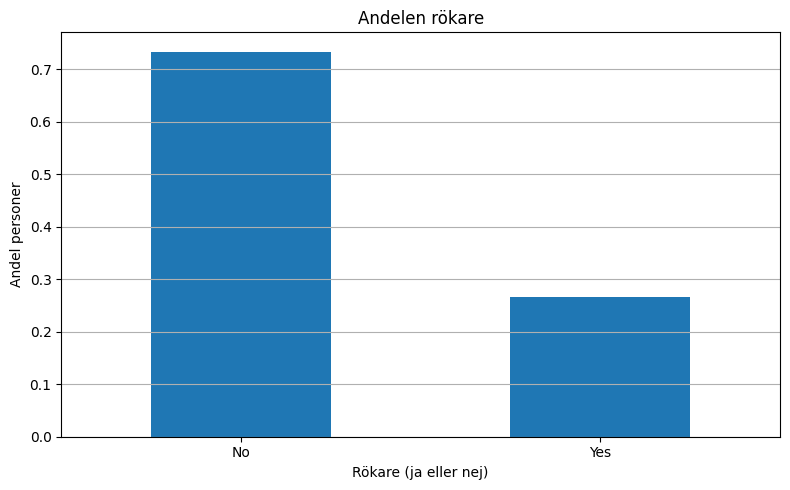

In [4]:
healthviz.plot_bar(column="smoker",
    title="Andelen rökare",
    xlabel="Rökare (ja eller nej)",
    ylabel="Andel personer")

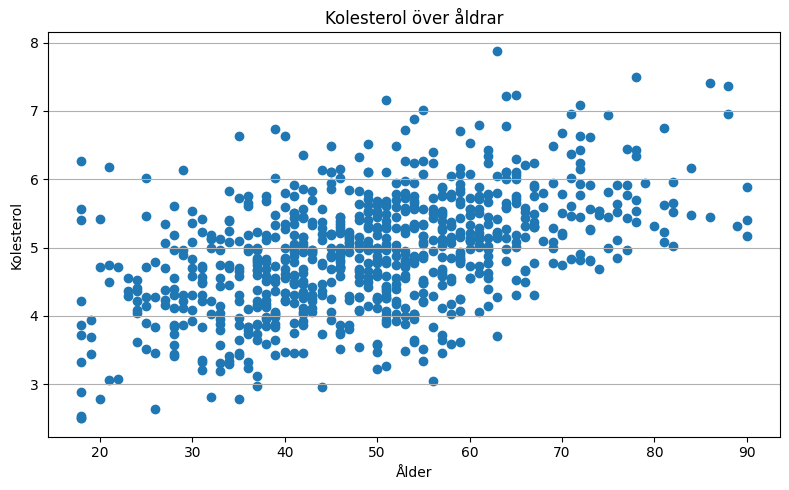

In [5]:
healthviz.plot_scatter(x_col="age",
    y_col="cholesterol",
    title="Kolesterol över åldrar",
    xlabel="Ålder",
    ylabel="Kolesterol")

### **Simulering**
Beräkna andelen personer i datasetet som har sjukdomen

In [6]:
h_analyzer.disease_stats()

Antal personer som har sjukdomen:0.06
Medel av 1000 simuleringar: 0.0590
Standardavvikelse: 0.0073




Antal personer med sjukdomen: **6% av personerna i datasetet har sjukdomen** 
Medelvärdet av 1000 simuleringar (1000 personer, upprepat 1000 gånger): **ca 0.059**

- Medel av simuleringarna: **ca 5.9%**
- Standardavvikelse: **ca 0.76 %-enheter**

Det simulerade medelvärdet (5.8%) ligger mycket nära den observerade andelen (6.00%)



### **Konfidensintervall**

- Beräkna ett konfidensintervall för medelvärdet av systoliskt blodtryck (systolic_bp)
    - Använde bootstrap metoden för beräkning

- Det genomsnittliga blodtrycket med 95% sannolikhet ligger ungefär mellan 148 mmHg och 150 mmHg

In [7]:
ci2 = h_analyzer.bootstrap_method()
print(f"95% konfidensintervall (bootstrap): [{ci2[0]:.2f}, {ci2[1]:.2f}]")

95% konfidensintervall (bootstrap): [148.30, 150.04]



### **Hypotesprövning**
#### Har rökare högre medel-blodtryck än icke-rökare?

- För att testa hypotesen har jag använt mig av bootstrap metoden.

In [8]:
from src.metrics import hypo_test

obs_diff, p_value, ci = hypo_test(df)
print(f"skillnaden:         {obs_diff}")
print(f"P-värdet:           {p_value}")
print(f"Konfidensintervall: {ci}")

skillnaden:         0.47190136846063524
P-värdet:           0.6756
Konfidensintervall: (-2.5444982044452757, 1.5828362965984837)



### **Resultat**

- Skillnaden i medelvärde mellan rökare och ickerökare är: **0.47 mmHg**
- P-värdet är: **ca 0.67%**
- 95% konfidensintervall ligger runt: **-2.5 och 1.6**

P-värdet är större än 0.05 och konfidensintervallet inkluderar 0, det går därmed inte att se någon större skillnad i medelblodtryck mellan rökare och icke-rökare baserat på datan från datasetet.

### Slutsats

Hypotesen att rökare skulle ha högre blodtryck än icke-rökare går inte stödja med den data som finns i datasetet.


### **Linjär regression**
- En linjär regression för att förutsäga blodtryck från vikt

In [9]:
intercept, slope, r2 = h_analyzer.linear_reg("weight", "systolic_bp")
print(f"""
----- Regression: vikt -> systoliskt blodtryck -----
Skärning                : {intercept: .3f}
Lutning                 : {slope: .4f}
R^2                     : {r2: .3f}""")


----- Regression: vikt -> systoliskt blodtryck -----
Skärning                :  136.862
Lutning                 :  0.1678
R^2                     :  0.032


#### **Resultat:**
- Blodtrycket ökar i genomsnitt ca 0.17 mmHg per extra kg. Ett väldigt svagt samband.
- 3.2% av andelen i systoliskt blodtryck kan förklaras av vikten. Vikt är inte tillräckligt för att påverka en persons blodtryck enligt denna data. 

### **Analys av systoliskt blodtryck per kön**

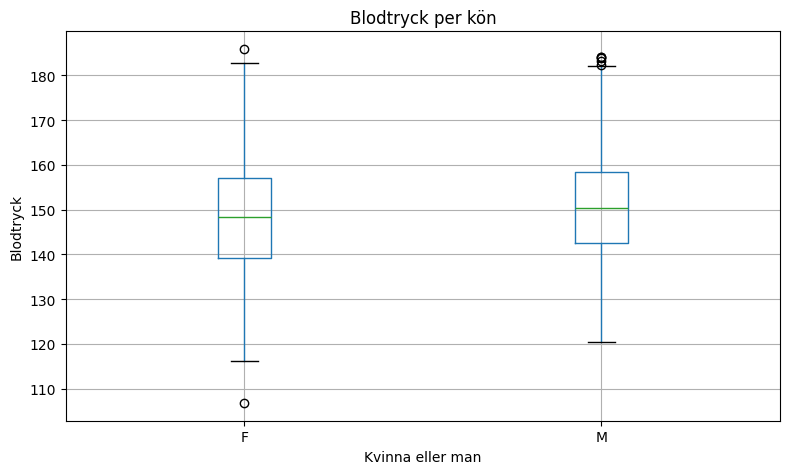

In [10]:
healthviz.plot_box("systolic_bp", "sex", "Blodtryck per kön", "Kvinna eller man", "Blodtryck")

### **Resultat**

##### Boxploten visar fördelningen av systoliskt blodtryck (mmHg) för män respektive kvinnor.

- Median värdet ligger något högre för män än för kvinnor
- Extremvärdena (outliers), det finns några för båda könen, vilket tyder på att ett fåtal individer har ovanligt höga eller låga blodtrycksvärden.
- Kvinnor har något lägre median, men har även några höga extremvären
- Män har en något högre median, och fler höga extremvärden

##### **Slutsats**
Vad man kan se från boxploten, män tenderar att ha ett något högre blodtryck än kvinnor, med väldigt liknande spridning mellan könen, och några extremvärden hos de båda. 